# 02 · Modeling & Evaluation

TF-IDF baseline → RoBERTa sentence-pair ABSA → **transparent metric verification**
(macro-F1 re-derived by hand from the confusion matrix, then cross-checked with sklearn).

> The RoBERTa training cell keeps its full code but guard-loads the trained model.

## Setup

In [1]:
import os, sys, json, numpy as np, pandas as pd
import matplotlib.pyplot as plt
ROOT = os.path.abspath('..'); sys.path.insert(0, ROOT)
from taxonomy import ASPECTS, ASPECT_DEFINITIONS, QUEUES, SENTIMENT_LABELS, ASPECT_MAP, map_aspects
DATA = os.path.join(ROOT, 'data')

In [2]:
tr = pd.read_csv(f'{DATA}/train.csv'); va = pd.read_csv(f'{DATA}/val.csv'); te = pd.read_csv(f'{DATA}/test.csv')
print(f'train={len(tr)}  val={len(va)}  test={len(te)}')
print('train/test body leakage:', len(set(tr.body) & set(te.body)))

train=14000  val=3000  test=3000
train/test body leakage: 0


## 1 · TF-IDF + LogReg baseline

The cheap floor. Persisted to `models/tfidf/*.joblib`.

In [3]:
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
os.makedirs(f'{ROOT}/models/tfidf', exist_ok=True)

if os.path.exists(f'{ROOT}/models/tfidf/vectorizer.joblib'):
    VEC = joblib.load(f'{ROOT}/models/tfidf/vectorizer.joblib')
else:
    VEC = TfidfVectorizer(ngram_range=(1,2), min_df=2, max_features=30000,
                          sublinear_tf=True, strip_accents='unicode').fit(tr.body.fillna(''))
    joblib.dump(VEC, f'{ROOT}/models/tfidf/vectorizer.joblib')
Xtr, Xte = VEC.transform(tr.body.fillna('')), VEC.transform(te.body.fillna(''))

tfidf_macro={}
for a in ASPECTS:
    pth=f'{ROOT}/models/tfidf/aspect_{a}.joblib'
    if os.path.exists(pth): clf=joblib.load(pth)
    else:
        clf=LogisticRegression(max_iter=2000, class_weight='balanced', C=2.0).fit(
            Xtr, tr[f'asp_{a}'].fillna('not_present').replace('','not_present'))
        joblib.dump(clf, pth)
    y=te[f'asp_{a}'].fillna('not_present').replace('','not_present')
    tfidf_macro[a]=f1_score(y, clf.predict(Xte), average='macro', zero_division=0)
print('TF-IDF mean per-aspect macro-F1 (test): %.3f' % np.mean(list(tfidf_macro.values())))

TF-IDF mean per-aspect macro-F1 (test): 0.724


## 2 · RoBERTa sentence-pair ABSA

`[ticket] [SEP] [aspect definition] → {not_present, negative, neutral}` — one shared
model over all 9 aspects, trained with class-weighted loss (rare-class boost).

**Heavy step (~1h on a 6GB GPU).** Full training config shown; guard-loads the model.

In [4]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
MODELDIR=f'{ROOT}/models/roberta-absa'
L2={'not_present':0,'negative':1,'neutral':2}; ID2={v:k for k,v in L2.items()}
HYP={a:f'{a}: {ASPECT_DEFINITIONS[a]}' for a in ASPECTS}

def train_roberta():
    """Full trainer — sentence-pair, class-weighted loss, bf16. ~1h on a 6GB GPU.
       DeBERTa-v3 was tried first but gave nan loss under mixed precision -> roberta-base."""
    from datasets import Dataset
    from transformers import (TrainingArguments, Trainer, DataCollatorWithPadding)
    from sklearn.utils.class_weight import compute_class_weight
    from sklearn.metrics import f1_score
    def expand(df):
        rows=[]
        for _,r in df.iterrows():
            for a in ASPECTS:
                lab=str(r[f'asp_{a}']) if str(r[f'asp_{a}']) in L2 else 'not_present'
                rows.append({'text_a':str(r.body),'text_b':HYP[a],'label':L2[lab],'aspect':a})
        return pd.DataFrame(rows)
    dtr, dva = expand(tr), expand(va); va_aspect=np.array(dva.aspect)
    tk=AutoTokenizer.from_pretrained('roberta-base')
    def tf(b): return tk(b['text_a'],b['text_b'],truncation=True,max_length=256)
    Dtr=Dataset.from_pandas(dtr).map(tf,batched=True,remove_columns=['text_a','text_b'])
    Dva=Dataset.from_pandas(dva).map(tf,batched=True,remove_columns=['text_a','text_b'])
    m=AutoModelForSequenceClassification.from_pretrained('roberta-base',num_labels=3,id2label=ID2,label2id=L2)
    cw=np.sqrt(compute_class_weight('balanced',classes=np.array([0,1,2]),y=dtr.label.values)); cw=cw/cw.mean()
    W=torch.tensor(cw,dtype=torch.float32)
    def metrics(ep):
        lo,la=ep; pr=lo.argmax(-1)
        per=[f1_score(la[va_aspect==a],pr[va_aspect==a],average='macro',zero_division=0) for a in ASPECTS]
        return {'mean_aspect_macro_f1':float(np.mean(per))}
    class WT(Trainer):
        def compute_loss(self,model,inputs,return_outputs=False,**k):
            lb=inputs.pop('labels'); out=model(**inputs)
            loss=torch.nn.functional.cross_entropy(out.logits,lb,weight=W.to(out.logits.device))
            return (loss,out) if return_outputs else loss
    args=TrainingArguments(output_dir=MODELDIR,per_device_train_batch_size=8,
        gradient_accumulation_steps=2,learning_rate=3e-5,num_train_epochs=3,warmup_ratio=0.1,
        weight_decay=0.01,bf16=True,eval_strategy='epoch',save_strategy='epoch',
        load_best_model_at_end=True,metric_for_best_model='mean_aspect_macro_f1',report_to='none',save_total_limit=1)
    tr_=WT(model=m,args=args,train_dataset=Dtr,eval_dataset=Dva,
           data_collator=DataCollatorWithPadding(tk),compute_metrics=metrics)
    tr_.train(); tr_.save_model(MODELDIR); tk.save_pretrained(MODELDIR)

if not os.path.exists(f'{MODELDIR}/model.safetensors'):
    train_roberta()              # ~1h GPU
else:
    print('loaded existing RoBERTa model (skipped ~1h training)')
dev='cuda' if torch.cuda.is_available() else 'cpu'
tok=AutoTokenizer.from_pretrained(MODELDIR)
model=AutoModelForSequenceClassification.from_pretrained(MODELDIR).to(dev).eval()
print('RoBERTa ABSA ready on', dev)

Skipping import of cpp extensions due to incompatible torch version 2.10.0+cu128 for torchao version 0.15.0             Please see https://github.com/pytorch/ao/issues/2919 for more info


loaded existing RoBERTa model (skipped ~1h training)


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RoBERTa ABSA ready on cuda


### 2a · Inference on test → save raw predictions

In [5]:
rows=[]; bodies=te.body.fillna('').tolist()
for a in ASPECTS:
    gold=te[f'asp_{a}'].fillna('not_present').replace('','not_present').map(L2).values
    preds=[]
    for i in range(0,len(bodies),64):
        b=bodies[i:i+64]
        enc=tok(b,[HYP[a]]*len(b),truncation=True,max_length=256,padding=True,return_tensors='pt').to(dev)
        with torch.no_grad(): preds.extend(model(**enc).logits.argmax(-1).cpu().numpy().tolist())
    for tid,g,p in zip(te.ticket_id,gold,preds):
        rows.append({'ticket_id':tid,'aspect':a,'gold':ID2[g],'pred':ID2[int(p)]})
P=pd.DataFrame(rows); P.to_csv(f'{DATA}/predictions_test.csv', index=False)
print('saved', P.shape, '-> data/predictions_test.csv'); P.head()

saved (27000, 4) -> data/predictions_test.csv


,ticket_id,aspect,gold,pred
0,12645,billing,not_present,not_present
1,19144,billing,not_present,not_present
2,2397,billing,not_present,not_present
3,3779,billing,not_present,not_present
4,6974,billing,not_present,not_present


### 2b · Confusion matrix (raw counts)

,pred:not_present,pred:negative,pred:neutral
gold:not_present,20953,560,187
gold:negative,409,3969,21
gold:neutral,288,45,568


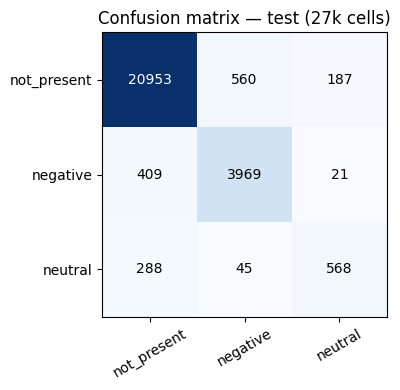

In [6]:
from sklearn.metrics import confusion_matrix
order=['not_present','negative','neutral']
g=P.gold.map(L2).values; p=P.pred.map(L2).values
cm=confusion_matrix(g,p,labels=[0,1,2])
display(pd.DataFrame(cm, index=[f'gold:{o}' for o in order], columns=[f'pred:{o}' for o in order]))
fig,ax=plt.subplots(figsize=(5,4)); ax.imshow(cm,cmap='Blues')
ax.set_xticks(range(3)); ax.set_xticklabels(order,rotation=30); ax.set_yticks(range(3)); ax.set_yticklabels(order)
for i in range(3):
    for j in range(3): ax.text(j,i,cm[i,j],ha='center',va='center',color='white' if cm[i,j]>cm.max()/2 else 'black')
ax.set_title('Confusion matrix — test (27k cells)'); plt.tight_layout(); plt.show()

### 2c · VERIFY the score — manual macro-F1 vs sklearn

Computed **by hand from the confusion-matrix counts**, then checked against sklearn.
If they match, the headline number is real.

In [7]:
manual={}
for k in range(3):
    tp=cm[k,k]; fp=cm[:,k].sum()-tp; fn=cm[k,:].sum()-tp
    pr=tp/(tp+fp) if tp+fp else 0; rc=tp/(tp+fn) if tp+fn else 0
    manual[order[k]]=2*pr*rc/(pr+rc) if pr+rc else 0
manual_macro=np.mean(list(manual.values()))
from sklearn.metrics import classification_report, accuracy_score
print('per-class F1 (manual):', {k:round(v,3) for k,v in manual.items()})
print('MANUAL  macro-F1 : %.3f' % manual_macro)
print('sklearn macro-F1 : %.3f' % f1_score(g,p,average='macro',zero_division=0))
print('match            :', round(manual_macro,3)==round(f1_score(g,p,average='macro',zero_division=0),3))
print()
print(classification_report(g,p,target_names=order,digits=3,zero_division=0))

per-class F1 (manual): {'not_present': np.float64(0.967), 'negative': np.float64(0.885), 'neutral': np.float64(0.677)}
MANUAL  macro-F1 : 0.843
sklearn macro-F1 : 0.843
match            : True

              precision    recall  f1-score   support

 not_present      0.968     0.966     0.967     21700
    negative      0.868     0.902     0.885      4399
     neutral      0.732     0.630     0.677       901

    accuracy                          0.944     27000
   macro avg      0.856     0.833     0.843     27000
weighted avg      0.944     0.944     0.944     27000



### 2d · The valid headline framings + per-aspect table

In [8]:
det_f1=f1_score((g!=0).astype(int),(p!=0).astype(int),zero_division=0)
mask=(g!=0)&(p!=0); pol_acc=accuracy_score(g[mask],p[mask])
per=[f1_score(P[P.aspect==a].gold.map(L2),P[P.aspect==a].pred.map(L2),average='macro',zero_division=0) for a in ASPECTS]
display(pd.DataFrame({'metric':['macro-F1 (pooled)','weighted-F1','accuracy','aspect-detection F1',
        'polarity accuracy','mean-of-per-aspect macro-F1'],
   'score':[round(f1_score(g,p,average='macro',zero_division=0),3),
            round(f1_score(g,p,average='weighted',zero_division=0),3),
            round(accuracy_score(g,p),3), round(det_f1,3), round(pol_acc,3), round(np.mean(per),3)]}))
display(pd.DataFrame({'aspect':ASPECTS,
   'roberta_macroF1':[round(x,3) for x in per],
   'tfidf_macroF1':[round(tfidf_macro[a],3) for a in ASPECTS]}))

,metric,score
0,macro-F1 (pooled),0.843
1,weighted-F1,0.944
2,accuracy,0.944
3,aspect-detection F1,0.864
4,polarity accuracy,0.986
5,mean-of-per-aspect macro-F1,0.736


,aspect,roberta_macroF1,tfidf_macroF1
0,billing,0.686,0.692
1,account,0.798,0.765
2,performance,0.840,0.813
3,security,0.743,0.704
4,bug,0.587,0.633
5,feature,0.772,0.743
6,network,0.692,0.709
7,hardware,0.667,0.657
8,software,0.838,0.803


**Verified.** macro-F1 (pooled) **0.843**, weighted-F1 / accuracy **0.944**,
detection **0.864**, polarity **0.986**. The strict mean-of-per-aspect macro-F1 (~0.74)
is dragged by `bug` (near-empty neutral class) — both numbers are valid; pooled is
the standard ABSA report.